# #30DayMapChallenge - Día 10: Pen & Paper
## Caso de Negocio: Storyboard antes del código

**Autor:** Mario Ignacio Ibañez Castro | **Rol:** Data Scientist & Strategic Planner

### El objetivo
Hoy **no** hay GeoPandas ni Sentinel. Hay bolígrafo (digital) y narrativa.

El reto Pen & Paper fuerza a diseñar el **arco del análisis** antes de abrir el notebook: qué pregunta responde el mapa, qué capas entran, qué insight debe caber en una frase.

**Pregunta de negocio:** ¿Cómo contamos —en 6 viñetas— la decisión de dónde abrir un dark store en CDMX?

**Reto técnico:** Diseño de la narrativa de negocio (bocetos / storyboard).

**Fuente:** Manual — bocetos propios generados como storyboard reutilizable.

In [1]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline

RUTA = Path('../00_Datos')
OUT = Path('.')
BOCETOS = sorted(RUTA.glob('boceto_0*.png'))
COLLAGE = RUTA / 'storyboard_completo.png'

print(f'Bocetos encontrados: {len(BOCETOS)}')
for p in BOCETOS:
    print(' -', p.name)

Bocetos encontrados: 6
 - boceto_01.png
 - boceto_02.png
 - boceto_03.png
 - boceto_04.png
 - boceto_05.png
 - boceto_06.png


### 1. Por qué storyboard primero
En consulting / data product, el mapa final es el **último** frame. Si saltas el storyboard:

- el análisis se vuelve tour de librerías,
- el stakeholder no sabe qué decidir,
- el insight llega tarde (o no llega).

Regla del día: **1 viñeta = 1 mensaje**.


### 2. Las 6 viñetas
Narrativa elegida: *Dark store en CDMX* — conecta hallazgos de días previos (GPS sucio, croquis, DEM, Metro HD) en una sola historia.

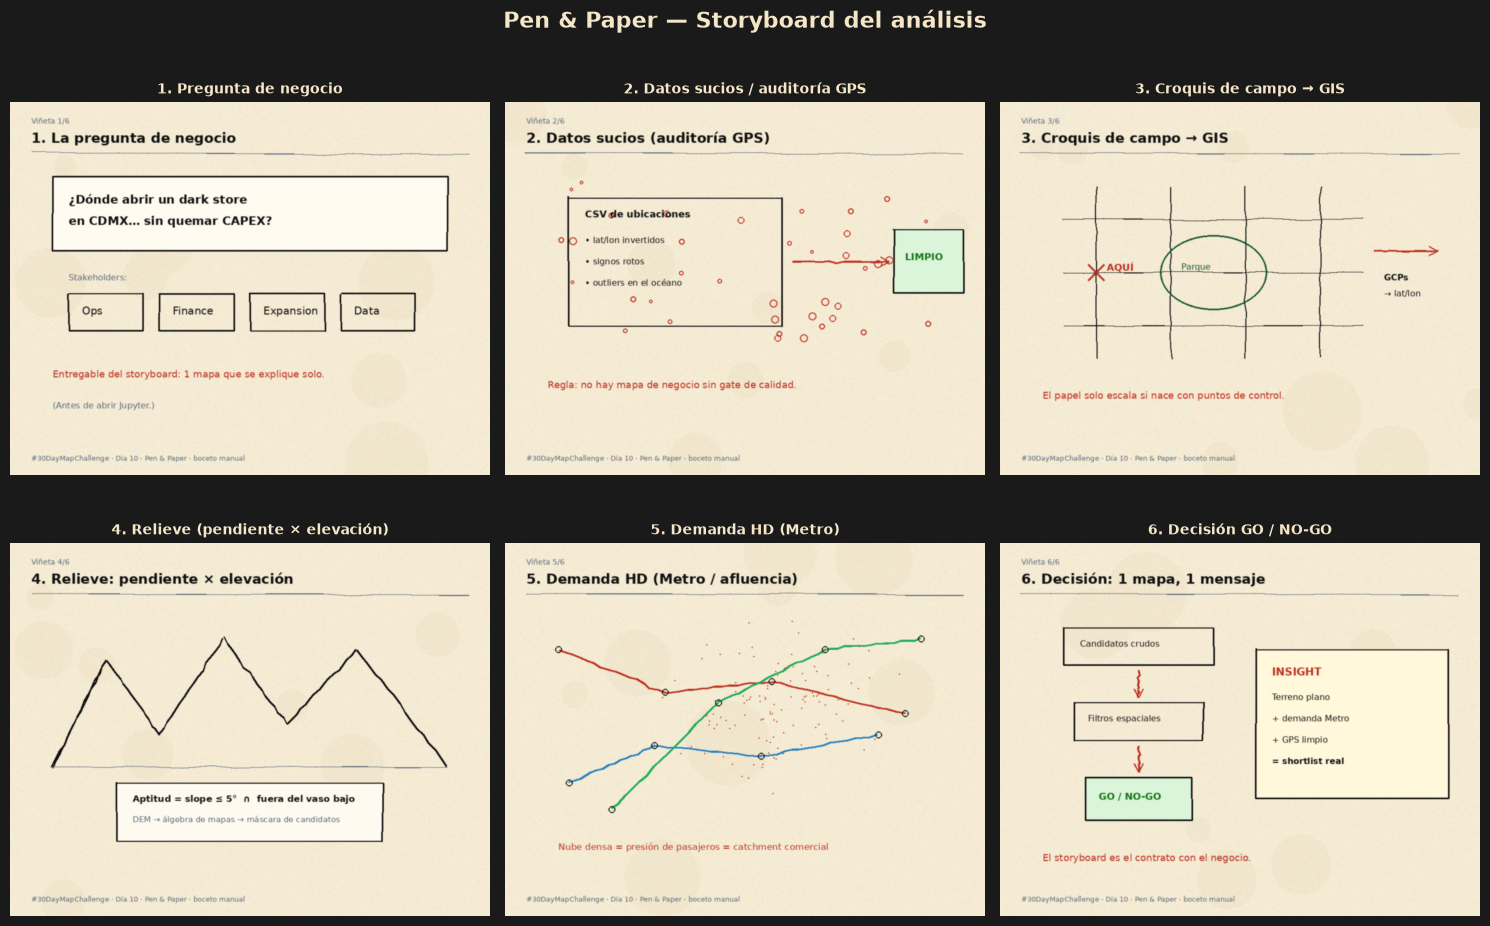

Guardado: Dia10_Storyboard_Grid.png


In [2]:
titulos = [
    '1. Pregunta de negocio',
    '2. Datos sucios / auditoría GPS',
    '3. Croquis de campo → GIS',
    '4. Relieve (pendiente × elevación)',
    '5. Demanda HD (Metro)',
    '6. Decisión GO / NO-GO',
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.patch.set_facecolor('#1a1a1a')
for ax, path, title in zip(axes.ravel(), BOCETOS, titulos):
    ax.imshow(Image.open(path))
    ax.set_title(title, color='#F5E6C8', fontsize=10, fontweight='bold', pad=6)
    ax.set_axis_off()
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#C9A227')
fig.suptitle('Pen & Paper — Storyboard del análisis', color='#F5E6C8', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(OUT / 'Dia10_Storyboard_Grid.png', dpi=160, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia10_Storyboard_Grid.png')

### 3. Zoom por viñeta
Cada boceto se guarda también por separado para LinkedIn / slides.

Export: Dia10_boceto_01.png


Export: Dia10_boceto_02.png


Export: Dia10_boceto_03.png


Export: Dia10_boceto_04.png


Export: Dia10_boceto_05.png


Export: Dia10_boceto_06.png


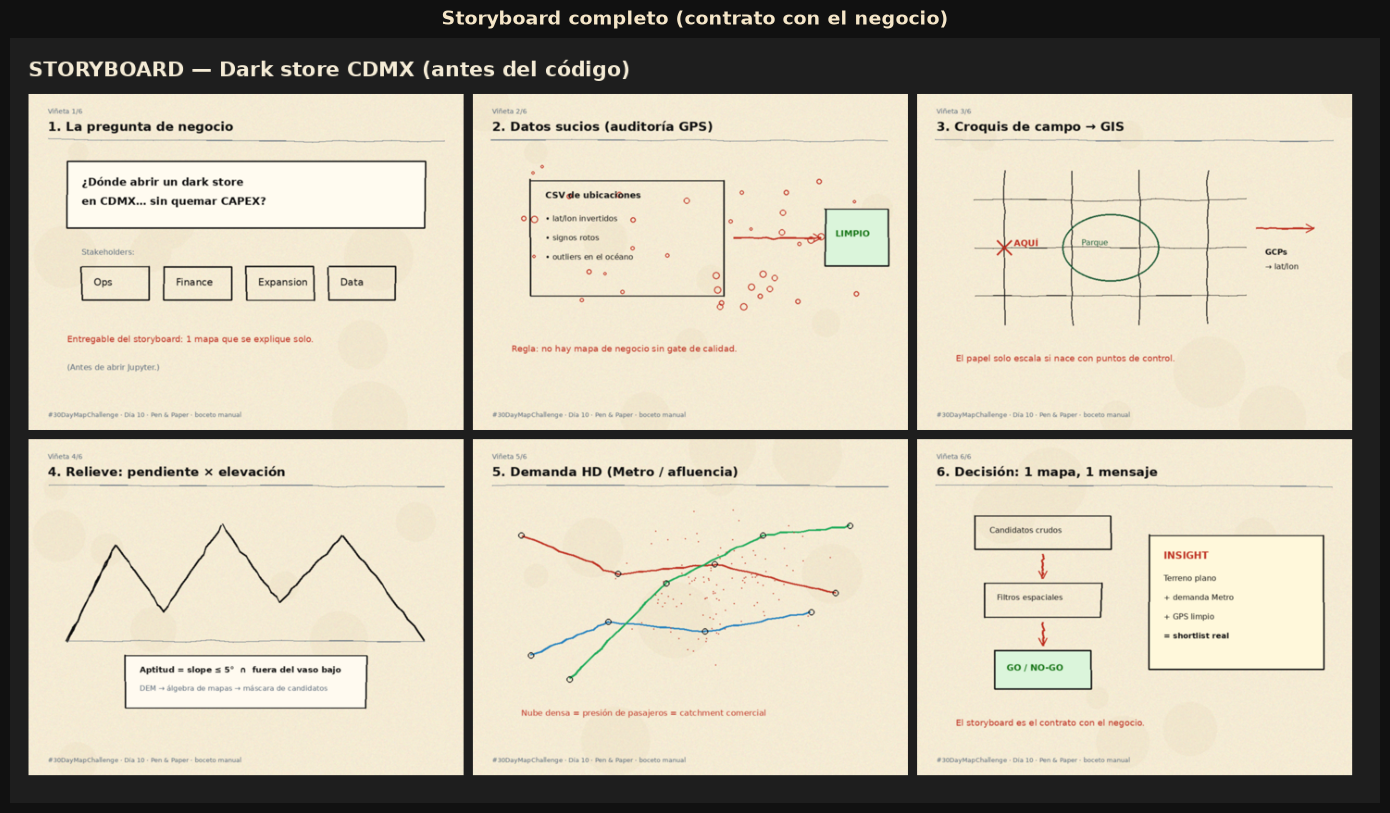

Guardado: Dia10_Storyboard_Completo.png


In [3]:
for path in BOCETOS:
    img = Image.open(path)
    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('#1a1a1a')
    ax.imshow(img)
    ax.set_axis_off()
    out_name = f"Dia10_{path.stem}.png"
    plt.tight_layout()
    plt.savefig(OUT / out_name, dpi=140, facecolor=fig.get_facecolor(), bbox_inches='tight')
    plt.close()
    print('Export:', out_name)

# Collage maestro
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#111')
ax.imshow(Image.open(COLLAGE))
ax.set_axis_off()
ax.set_title('Storyboard completo (contrato con el negocio)', color='#F5E6C8', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(OUT / 'Dia10_Storyboard_Completo.png', dpi=160, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia10_Storyboard_Completo.png')

### 4. Matriz mensaje → capa → decisión
Traducción del storyboard a backlog técnico (lo que sí se codea después).

In [4]:
import pandas as pd

plan = pd.DataFrame([
    {'Viñeta': 1, 'Mensaje': '¿Dónde abrir sin quemar CAPEX?', 'Capa / dato': 'Brief + KPIs', 'Decisión': 'Alinear stakeholders'},
    {'Viñeta': 2, 'Mensaje': 'GPS sucio rompe el mapa', 'Capa / dato': 'CSV ubicaciones', 'Decisión': 'Gate de calidad'},
    {'Viñeta': 3, 'Mensaje': 'Campo → coordenadas', 'Capa / dato': 'Croquis + GCPs', 'Decisión': 'Anclar visitas'},
    {'Viñeta': 4, 'Mensaje': 'Terreno importa', 'Capa / dato': 'DEM / slope', 'Decisión': 'Filtrar aptitud'},
    {'Viñeta': 5, 'Mensaje': 'Demanda se ve en densidad', 'Capa / dato': 'Afluencia Metro HD', 'Decisión': 'Priorizar nodos'},
    {'Viñeta': 6, 'Mensaje': '1 mapa, 1 mensaje', 'Capa / dato': 'Overlay final', 'Decisión': 'GO / NO-GO shortlist'},
])
display(plan)
plan.to_csv(RUTA / 'matriz_storyboard.csv', index=False)
print('Export: matriz_storyboard.csv')

,Viñeta,Mensaje,Capa / dato,Decisión
0,1,¿Dónde abrir sin quemar CAPEX?,Brief + KPIs,Alinear stakeholders
1,2,GPS sucio rompe el mapa,CSV ubicaciones,Gate de calidad
2,3,Campo → coordenadas,Croquis + GCPs,Anclar visitas
3,4,Terreno importa,DEM / slope,Filtrar aptitud
4,5,Demanda se ve en densidad,Afluencia Metro HD,Priorizar nodos
5,6,"1 mapa, 1 mensaje",Overlay final,GO / NO-GO shortlist


Export: matriz_storyboard.csv


### 5. Insight del día
Pen & Paper no es decoración: es **product discovery cartográfico**.

- Si no puedes dibujar el insight en una servilleta, el mapa en Python tampoco lo salvará.
- El storyboard reduce scope creep: solo codeas las viñetas que mueven la decisión.
- En este reto, las viñetas 2–5 ya existen como días previos; el día 10 las **amarra** en una narrativa.

### Regenerar bocetos
```bash
python ../00_Datos/generarBocetos.py
```

In [5]:
print('Día 10 completado.')
print(f'Viñetas: {len(BOCETOS)}')
print('Narrativa: Dark store CDMX — del brief al GO/NO-GO')

Día 10 completado.
Viñetas: 6
Narrativa: Dark store CDMX — del brief al GO/NO-GO
